<a href="https://colab.research.google.com/github/AcSsalazar/the-color-of-emotions/blob/main/Notebooks/4.3-training-building-a-cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implementación de Unidad Recurrente Bidireccional con Compuerta (BiGRU).

En este notebook vamos a levar a cabo el uso de una *Bidirectional gated recurrent Unit* por sus siglas en ingles *BiGRU*, es una variante avanzada de las Redes Neuronales Recurrentes (RNN) que mejora el procesamiento de secuencias al analizar los datos en ambas direcciones: de principio a fin (hacia adelante) y de fin a principio (hacia atrás). Esta arquitectura combina dos capas de Unidades Recurrentes con Compuerta (GRU) independientes para capturar el contexto tanto pasado como futuro de cada elemento en una secuencia. Para sacar provecho de los canales que conservan la dimension temporal en nuestros tensores, es decir los canales correspondientes al delta del mel-spec y a espectrograma *cohclear db*.

Cabe destacar que, para las primeros bloques de la arquitectura de la Red Neuronal, se usan unidades estandar del tipo Convolusional, de manera que, nuestra arquitectura posee la siguiente estructura base:

## Monitoreo con Weights & Biases

Para optimizar el rendimiento de nuestra arquitectura CBGRU (CNN + BiGRU), integramos Weights & Biases (W&B) como plataforma central de experimentación. En modelos híbridos complejos, es crítico entender cómo interactúan las capas convolucionales y las recurrentes.

**Seguimiento (Tracking)**: Registro en tiempo real de métricas (pérdida, precisión), hiperparámetros y consumo de hardware (GPU/CPU).

**Visualización**: Tableros interactivos para comparar ejecuciones y analizar el rendimiento del modelo.

**Artefactos**: Control de versiones para datasets y modelos, garantizando la trazabilidad y reproducibilidad.

**Barrido (Sweeps)**: Automatización de la búsqueda de los mejores hiperparámetros para optimizar el modelo.

El objetivo es:

* Registrar cada ejecución (hiperparámetros + métricas + artefactos)

* Seleccionar el mejor punto de control usando solo la validación.

* Evaluar una sola vez al final para evitar la fuga de datos de las pruebas.

* Constatar la evolución de los modelos y sus diferentes arquitecturas.

* Obener un modelo final para su inferencia y despliegue a partir de la verificación de su rendimiento despúes de la respectiva experimentación.


### 1.0 Imports y configuración base


In [2]:
# Imports
#------------------------------------------------------------------------------------------
import os
import copy
import numpy as np
import torch
import xgboost as xgb
import random as random
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd
import time
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torchaudio import transforms as T
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay,f1_score, accuracy_score)
from google.colab import drive
from tqdm import tqdm
from collections import Counter

In [3]:
# ─── Instalación de Weights & Biases ────────────────────────────────
# Descomenta las líneas siguientes si wandb no está instalado en tu entorno:
!pip install wandb -q

# Para autenticarte (solo la primera vez por sesión de Colab):
import wandb; wandb.login()

# USE_WANDB se define en la celda de configuración más abajo.
# Déjalo en False para ejecutar sin tracking remoto.

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: acsalazar (acsalazar-numbral) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
# Semilla y runtime
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


### 1.2 Carga de tensores desde Drive (train/val/test)

Los archivos `.pt` generados en el notebook 3.2 contienen un diccionario con `x`, `y`,
metadatos y el mapeo de clases. Ajusta `BASE_DIR_TENSOR` según tu ruta local/Drive.


In [7]:
drive.mount('/content/drive')
! cp -r /content/drive/MyDrive/split_pytorch_tensors /content/split_pytorch_tensors

Mounted at /content/drive


In [8]:
BASE_DIR_TENSOR = '/content/split_pytorch_tensors'
BATCH_SIZE = 32

SPLIT_FILES = {
    'train': 'train_tensors.pt',
    'val': 'val_tensors.pt',
    'test': 'test_tensors.pt',
}

def load_pack(split_name: str):
    path = os.path.join(BASE_DIR_TENSOR, SPLIT_FILES[split_name])
    if not os.path.exists(path):
        raise FileNotFoundError(f'No existe el archivo: {path}')
    return torch.load(path, map_location='cpu', weights_only=False)

# Cargamos lo packs en variables aun no son tensores puros
train_pack = load_pack('train')
val_pack = load_pack('val')
test_pack = load_pack('test')

# Verificamos las clases del diccionario dentro del pack
class_to_idx = train_pack['class_to_idx']
idx_to_class = {v: k for k, v in class_to_idx.items()}
class_names = [idx_to_class[i] for i in sorted(idx_to_class.keys())]
print('Clases:', class_names)
print('Shape train:', tuple(train_pack['x'].shape))

Clases: ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Shape train: (7422, 3, 60, 51)


### 1.3 Estrategia de normalización y augmentation

**Normalización:**  
Los tensores provienen del notebook `3.2` y ya fueron normalizados con **z-score por muestra y canal** (`zscore_per_channel`). No se aplica una segunda normalización a nivel de dataset para evitar doble normalización.

**Augmentation online (desactivado por defecto):**  
El notebook `3.2` ya añadió muestras extra de `surprised` con **ruido** y **shift temporal** durante la exportación (augmentación *offline*). Por eso `augment=False` es el valor por defecto en `build_dataloaders`: la augmentación offline ya aporta robustez sin el riesgo de distorsionar demasiado las entradas.  
Si se desea augmentación online adicional, se puede activar `augment=True`; en ese caso se aplica exclusivamente **SpecAugment** (FrequencyMasking + TimeMasking), más un pequeño ruido gaussiano opcional.

**Early stopping y scheduler:**  
Se usa **macro-F1** como criterio en lugar de `val_loss`, ya que es más informativo para datasets desbalanceados y refleja mejor el objetivo de clasificación equitativa entre clases.


In [9]:
class TensorPackDataset(Dataset):
  def __init__(self, pack, augment=False):
      self.x = pack['x'].float() # [N, 3, n_mels, targetframes]
      self.y = pack['y'].long()  # len(N)
      self.augment = augment

      # Definimos las transformaciones de SpecAugment
      # Ajustar n_freq_masks y n_time_masks según el tamaño (60x51)
      if augment:
          self.spec_aug = nn.Sequential(
              T.FrequencyMasking(freq_mask_param=4), # Enmascara hasta 4 bins de mel
              T.TimeMasking(time_mask_param=2)       # Enmascara hasta 2 frames de tiempo
          )

  def __len__(self):
      return self.y.shape[0]

  def __getitem__(self, idx):
      x = self.x[idx]
      y = self.y[idx]

      if self.augment:
          # SpecAugment espera [batch, channel, freq, time] o [channel, freq, time]
          # Aplicamos la misma máscara a los 3 canales (Mel spec, delta, Cochlear)
          x = self.spec_aug(x)

          # Opcional: Pequeño ruido gaussiano
          if random.random() < 0.5:
              x = x + 0.01 * torch.randn_like(x)

      return x, y

### 1.4 Configuracion Early Stop

In [10]:
class EarlyStopping:
    """Early stopping configurable para minimizar (val_loss) o maximizar (val_f1)."""
    def __init__(self, patience=5, min_delta=0.0, mode="min"):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode  # "min" para loss, "max" para F1
        self.best = None
        self.counter = 0

    def step(self, metric):
        """Devuelve True cuando se debe detener el entrenamiento."""
        if self.best is None:
            self.best = metric
            return False
        improved = (metric > self.best + self.min_delta) if self.mode == "max" \
                   else (metric < self.best - self.min_delta)
        if improved:
            self.best = metric
            self.counter = 0
            return False
        self.counter += 1
        print(f"Early Stopping: {self.counter}/{self.patience} (best={self.best:.4f})")
        return self.counter >= self.patience


### 1.5 Dataloaders

In [11]:
# Solo aumentamos el set de TRAIN. Val y Test deben quedar puros.
def build_dataloaders(batch_size=BATCH_SIZE):
    pin = torch.cuda.is_available()
    # Valor por defecto: augment= False
    train_ds = TensorPackDataset(train_pack, augment=False)
    val_ds = TensorPackDataset(val_pack, augment=False)
    test_ds = TensorPackDataset(test_pack, augment=False)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=pin)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=pin)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=pin)

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = build_dataloaders()


### 1.6 Definición de la CGRU


In [12]:
class EmotionCGRU(nn.Module):
    def __init__(self, num_classes, classifier_dropout=0.5):
        super().__init__()

        self.cnn = nn.Sequential(
            # Bloque Convolucional 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 1)), # Frec: 60 -> 30, Tiempo: 51 -> 51

            # Bloque Convolucional 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 1)), # Frec: 30 -> 15, Tiempo: 51 -> 51
            nn.Dropout2d(0.1),

            # Bloque Convolucional 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.05),

            # Forzamos frecuencia a 8 (15 -> 8), mantenemos Tiempo intacto con = None -> 51
            nn.AdaptiveAvgPool2d((8, None))
        )

        # 128 canales * 8 bins de frecuencia = 1024
        self.gru_input_size = 128 * 8

        self.bigru = nn.GRU(
            input_size=self.gru_input_size,
            hidden_size=128,
            num_layers=2,
            bidirectional=True,
            batch_first=True
        )

        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(classifier_dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # Entrada: (Batch, 3, 60, 51)
        x = self.cnn(x) # Salida: (Batch, 128, 8, 51)

        batch_size, channels, freq, time = x.size()

        # Formatear para GRU: (Batch, Tiempo, Features)
        # 1. Permutamos a (Batch, Tiempo, Canales, Frecuencia) -> (Batch, 51, 128, 8)
        x = x.permute(0, 3, 1, 2).contiguous()
        # 2. Aplanamos a (Batch, 51, 1024)
        x = x.view(batch_size, time, channels * freq)

        gru_out, _ = self.bigru(x)
        # Promedio temporal de las salidas de la GRU
        x = gru_out.mean(dim=1)
        return self.classifier(x)

## Tracking con Weights & Biases (W&B)

En los cuadernos de Colab/Jupyter, volver a ejecutar las celdas a menudo sobrescribe variables y resultados, lo que facilita la pérdida de:

* Qué hiperparámetros produjeron el mejor modelo y
las curvas de entrenamiento completas (pérdida/F1 vs. época).

* El mejor punto de control para esa ejecución, la matriz de confusión y
informe de clasificación asociado a ese punto de control.

***W&B*** soluciona esto almacenando las ejecuciones en un registro de experimentos externo, donde cada ejecución incluye:

1. Aspectos de la configuración `(wandb.config)` como por ejemplo: `dropout`,`seeds`,`weight decay`,`Learnig rate`, etc.

2. La serie temporal de métricas por época `train val loss`, `macro-F1`, `LR`.

3. Artefactos como puntos de control del modelo e informes.

### 2.0 Configuración de W&B

El baseline se contruye a partir de experimentacion anterior donde se obtuvo mayor estabilidad con un `BATCH_SIZE=32`, y como mencionamos antes sin *online data augmentation*, aunque se conservan estas funcionalidades con motivos investigativos, para futuros usuarios.

In [13]:
# --- Configuración de W&B y matriz de experimentos -----------------------------

# Establece USE_WANDB = True para registrar experimentos en Weights & Biases.
# Requiere wandb instalado (!pip install wandb -q) y autenticado con API key.
USE_WANDB      = True                # ← cambiar a True para activar tracking
WANDB_PROJECT  = "tcoe-experiments"
WANDB_GROUP    = "cnn-cgru-batch32"  # agrupa los cuatro experimentos en la misma vista (Mul útil)

# --- Hiperparámetros que son fijos en los cuatro experimentos-------------------

# Baseline confirmado: BATCH_SIZE=32, augment=False (sin SpecAugment online),

EPOCHS              = 50
LABEL_SMOOTHING     = 0.05
MAX_GRAD_NORM       = 1.0
EARLY_STOP_PATIENCE = 8    # patience mayor para que los drops de LR tomen efecto, no usar un valor menor a 4

# Directorio local para guardar los mejores checkpoints por ejecucion
CHECKPOINT_DIR = '/content/checkpoints_cnn'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# --- Matriz de experimentos (4 ejecuciones) ------------------------------------
# Scheduler fijo: ReduceLROnPlateau(mode='max', factor=0.5, patience=2) sobre val macro-F1.
# Gradient clipping: max_norm=1.0.  Label smoothing: 0.05.

RUN_MATRIX = [
    # Run 1 — baseline fuerte: LR conservador, dropout estándar, pesos de clase
    {
        "run_name": "run1_lr3e4_wd1e3_do05_cw",
        "lr": 3e-4, "weight_decay": 1e-3,
        "classifier_dropout": 0.5,
        "use_class_weights": True,
    },
    # Run 2 — LR más alto: explorar convergencia más rápida
    {
        "run_name": "run2_lr5e4_wd1e3_do05_cw",
        "lr": 5e-4, "weight_decay": 1e-3,
        "classifier_dropout": 0.5,
        "use_class_weights": True,
    },
    # Run 3 — dropout reducido: menos regularización en el clasificador
    {
        "run_name": "run3_lr3e4_wd1e3_do03_cw",
        "lr": 3e-4, "weight_decay": 1e-3,
        "classifier_dropout": 0.3,
        "use_class_weights": True,
    },
    # Run 4 — diagnóstico: sin pesos de clase (mide impacto del balanceo)
    {
        "run_name": "run4_lr3e4_wd1e3_do05_nocw",
        "lr": 3e-4, "weight_decay": 1e-3,
        "classifier_dropout": 0.5,
        "use_class_weights": False,
    },
]


### 4. Entrenamiento y validación


In [14]:
# TRAIN
#-------------------------------------------------------------------------------
# Calcular pesos de clase: total / (n_clases * counts)
# Esto da más peso a las clases con menos muestras.
''''surprised' tiene muestras extra desde la exportación offline, por lo que su peso
    resultante será menor que otras clases sub-representadas.'''

y_train_cpu = train_pack['y'].numpy()
label_counts = Counter(y_train_cpu)
total_samples = len(y_train_cpu)
num_classes = len(class_names)

class_weights = []
for i in range(num_classes):
    count = label_counts.get(i, 1)
    weight = total_samples / (num_classes * count)
    class_weights.append(weight)

class_weights_tensor = torch.FloatTensor(class_weights).to(device)
print(f"Pesos calculados para CrossEntropyLoss: {class_weights}")


def train_one_epoch(model, loader, criterion, optimizer, device, epoch=None, max_grad_norm=1.0):
    model.train()
    running_loss = 0.0
    running_correct = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch:02d} [train]", leave=False)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        # Gradient clipping para estabilizar el entrenamiento del GRU
        if max_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_correct += (outputs.argmax(1) == labels).sum().item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = running_correct / len(loader.dataset)
    return epoch_loss, epoch_acc


# VAL
#-------------------------------------------------------------------------------
@torch.no_grad()
def evaluate(model, loader, criterion, device, epoch=None):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    all_preds, all_targets = [], []

    pbar = tqdm(loader, desc=f"Epoch {epoch:02d} [val]", leave=False)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * inputs.size(0)
        running_correct += (outputs.argmax(1) == labels).sum().item()
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_targets.extend(labels.cpu().numpy())
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = running_correct / len(loader.dataset)
    # Macro-F1: métrica clave para datasets desbalanceados con objetivo de clasificación equitativa
    epoch_f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    return epoch_loss, epoch_acc, epoch_f1


# TEST / PREDICCIONES
#-------------------------------------------------------------------------------
@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_targets = [], []
    for inputs, labels in loader:
        outputs = model(inputs.to(device))
        all_preds.append(outputs.argmax(1).cpu().numpy())
        all_targets.append(labels.numpy())
    return np.concatenate(all_targets), np.concatenate(all_preds)


Pesos calculados para CrossEntropyLoss: [0.9000727625515401, 0.9000727625515401, 0.9000727625515401, 0.9000727625515401, 0.9638961038961039, 0.9000727625515401, 2.4543650793650795]



  INICIANDO: run1_lr3e4_wd1e3_do05_cw
  lr=0.0003  wd=0.001  dropout=0.5  class_weights=True



[20:33:21] Epoca 01/50 | Train loss 1.6694 acc 0.3222 | Val loss 1.6620 acc 0.3313 f1 0.2659 | lr 3.0e-04 | Time 6.4s


[20:33:25] Epoca 02/50 | Train loss 1.4912 acc 0.4099 | Val loss 1.5972 acc 0.3756 f1 0.3500 | lr 3.0e-04 | Time 4.3s


[20:33:29] Epoca 03/50 | Train loss 1.3985 acc 0.4582 | Val loss 1.5707 acc 0.4139 f1 0.3862 | lr 3.0e-04 | Time 4.4s


[20:33:34] Epoca 04/50 | Train loss 1.3098 acc 0.5015 | Val loss 1.4668 acc 0.4689 f1 0.4543 | lr 3.0e-04 | Time 4.6s


...

[20:35:18] Epoca 27/50 | Train loss 0.4528 acc 0.9426 | Val loss 1.5516 acc 0.6017 f1 0.6099 | lr 3.7e-05 | Time 4.6s
Early Stopping: 4/8 (best=0.6139)


[20:35:23] Epoca 28/50 | Train loss 0.4390 acc 0.9484 | Val loss 1.5610 acc 0.5957 f1 0.6101 | lr 3.7e-05 | Time 4.5s
Early Stopping: 5/8 (best=0.6139)


[20:35:27] Epoca 29/50 | Train loss 0.4356 acc 0.9479 | Val loss 1.5869 acc 0.6005 f1 0.6096 | lr 1.9e-05 | Time 4.4s
Early Stopping: 6/8 (best=0.6139)


[20:35:32] Epoca 30/50 | Train loss 0.4267 acc 0.9543 | Val loss 1.6100 acc 0.5849 f1 0.5973 | lr 1.9e-05 | Time 4.5s
Early Stopping: 7/8 (best=0.6139)


[20:35:37] Epoca 31/50 | Train loss 0.4178 acc 0.9576 | Val loss 1.6071 acc 0.5897 f1 0.6014 | lr 1.9e-05 | Time 4.6s
Early Stopping: 8/8 (best=0.6139)
Early stopping en epoch 31 (best val_f1=0.6139)

--- RESULTADO TEST [run1_lr3e4_wd1e3_do05_cw] ---
  best_epoch=23  best_val_f1=0.6139
  test_macro_f1=0.5926  test_acc=0.5987
              precision    recall  f1-score   support

       angry       0.73      0.81      0.77       149
     disgust       0.56      0.48      0.52       149
     fearful       0.61      0.39      0.48       149
       happy       0.60      0.56      0.58       149
     neutral       0.54      0.78      0.64       143
         sad       0.55      0.58      0.56       149
   surprised       0.75      0.50      0.60        24

    accuracy                           0.60       912
   macro avg       0.62      0.59      0.59       912
weighted avg       0.60      0.60      0.59       912



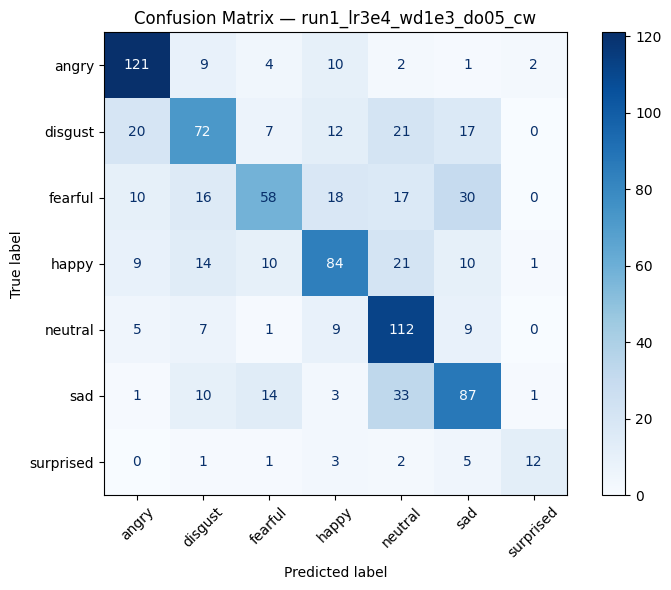

lr,██████████████▄▄▄▄▄▄▄▂▂▂▂▁▁▁▁▁▁
test_acc,▁
test_macro_f1,▁
train_acc,▁▂▂▃▃▄▄▄▅▅▅▅▅▆▆▆▇▇▇▇▇▇▇████████
train_loss,█▇▆▆▆▅▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val_acc,▁▂▃▅▅▅▆▇▇▇▇▇▇▇▇█▇███▇██████████
val_loss,█▇▆▄▃▄▂▂▂▂▂▁▃▃▂▃▄▄▅▄▅▅▅▆▇▇▆▆▇▇▇
val_macro_f1,▁▃▃▅▆▆▇▇▇▇▇█▇▇▇████▇▇██████████
lr,2e-05
test_acc,0.59868
test_macro_f1,0.59258



  INICIANDO: run2_lr5e4_wd1e3_do05_cw
  lr=0.0005  wd=0.001  dropout=0.5  class_weights=True



[20:35:53] Epoca 01/50 | Train loss 1.6537 acc 0.3239 | Val loss 1.6576 acc 0.3409 f1 0.2734 | lr 5.0e-04 | Time 4.6s


[20:35:58] Epoca 02/50 | Train loss 1.4717 acc 0.4237 | Val loss 1.5855 acc 0.3923 f1 0.3672 | lr 5.0e-04 | Time 4.5s


[20:36:03] Epoca 03/50 | Train loss 1.3797 acc 0.4737 | Val loss 1.5028 acc 0.4354 f1 0.4168 | lr 5.0e-04 | Time 4.7s


...

[20:37:13] Epoca 18/50 | Train loss 0.5753 acc 0.8831 | Val loss 1.5911 acc 0.5538 f1 0.5609 | lr 1.3e-04 | Time 4.6s
Early Stopping: 4/8 (best=0.5792)


[20:37:18] Epoca 19/50 | Train loss 0.5516 acc 0.8987 | Val loss 1.6277 acc 0.5598 f1 0.5691 | lr 1.3e-04 | Time 4.6s
Early Stopping: 5/8 (best=0.5792)


[20:37:23] Epoca 20/50 | Train loss 0.5257 acc 0.9054 | Val loss 1.6616 acc 0.5526 f1 0.5520 | lr 6.3e-05 | Time 4.7s
Early Stopping: 6/8 (best=0.5792)


[20:37:27] Epoca 21/50 | Train loss 0.4931 acc 0.9276 | Val loss 1.6643 acc 0.5634 f1 0.5715 | lr 6.3e-05 | Time 4.7s
Early Stopping: 7/8 (best=0.5792)


[20:37:32] Epoca 22/50 | Train loss 0.4780 acc 0.9320 | Val loss 1.6969 acc 0.5526 f1 0.5666 | lr 6.3e-05 | Time 4.6s
Early Stopping: 8/8 (best=0.5792)
Early stopping en epoch 22 (best val_f1=0.5792)

--- RESULTADO TEST [run2_lr5e4_wd1e3_do05_cw] ---
  best_epoch=14  best_val_f1=0.5792
  test_macro_f1=0.5830  test_acc=0.5855
              precision    recall  f1-score   support

       angry       0.73      0.74      0.74       149
     disgust       0.58      0.44      0.50       149
     fearful       0.52      0.52      0.52       149
       happy       0.57      0.54      0.55       149
     neutral       0.53      0.79      0.64       143
         sad       0.58      0.50      0.53       149
   surprised       0.85      0.46      0.59        24

    accuracy                           0.59       912
   macro avg       0.62      0.57      0.58       912
weighted avg       0.59      0.59      0.58       912



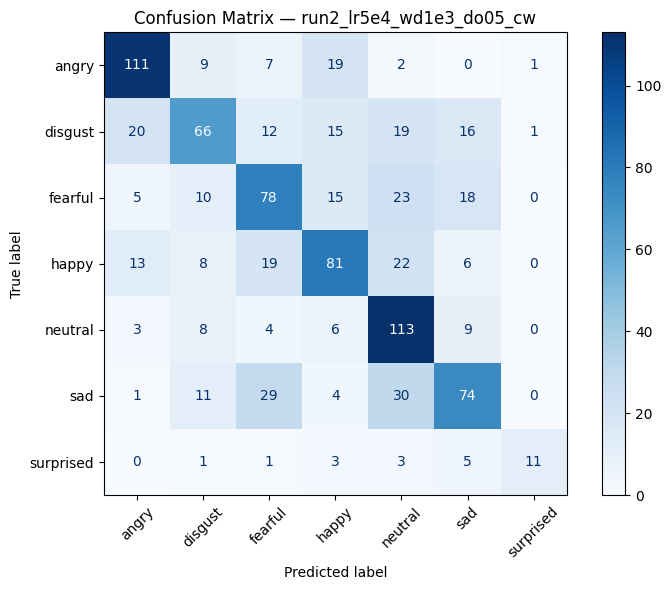

lr,██████████▄▄▄▄▄▄▂▂▂▁▁▁
test_acc,▁
test_macro_f1,▁
train_acc,▁▂▃▃▄▄▄▅▅▅▅▆▆▇▇▇▇▇████
train_loss,█▇▆▆▅▅▅▅▄▄▄▃▃▃▂▂▂▂▁▁▁▁
val_acc,▁▃▄▅▆▆▆█▇▇▇██████▇█▇█▇
val_loss,▇▆▄▃▂▃▁▁▂▂▂▃▃▃▅▄▆▆▇▇▇█
val_macro_f1,▁▃▄▅▆▆▇█▇▇▇███▇████▇██
lr,6e-05
test_acc,0.58553
test_macro_f1,0.58299



  INICIANDO: run3_lr3e4_wd1e3_do03_cw
  lr=0.0003  wd=0.001  dropout=0.3  class_weights=True



[20:37:48] Epoca 01/50 | Train loss 1.6311 acc 0.3398 | Val loss 1.6589 acc 0.3409 f1 0.2825 | lr 3.0e-04 | Time 4.7s


[20:37:53] Epoca 02/50 | Train loss 1.4496 acc 0.4314 | Val loss 1.5792 acc 0.3935 f1 0.3761 | lr 3.0e-04 | Time 5.0s


[20:37:57] Epoca 03/50 | Train loss 1.3627 acc 0.4702 | Val loss 1.5129 acc 0.4390 f1 0.4200 | lr 3.0e-04 | Time 4.7s


...

[20:39:27] Epoca 22/50 | Train loss 0.5352 acc 0.8995 | Val loss 1.5560 acc 0.5861 f1 0.5931 | lr 3.7e-05 | Time 4.6s
Early Stopping: 4/8 (best=0.5971)


[20:39:32] Epoca 23/50 | Train loss 0.5189 acc 0.9060 | Val loss 1.5605 acc 0.5921 f1 0.5966 | lr 3.7e-05 | Time 4.8s
Early Stopping: 5/8 (best=0.5971)


[20:39:37] Epoca 24/50 | Train loss 0.5175 acc 0.9096 | Val loss 1.5663 acc 0.5825 f1 0.5887 | lr 1.9e-05 | Time 4.7s
Early Stopping: 6/8 (best=0.5971)


[20:39:41] Epoca 25/50 | Train loss 0.4970 acc 0.9166 | Val loss 1.5869 acc 0.5897 f1 0.5936 | lr 1.9e-05 | Time 4.6s
Early Stopping: 7/8 (best=0.5971)


[20:39:46] Epoca 26/50 | Train loss 0.4909 acc 0.9225 | Val loss 1.5898 acc 0.5813 f1 0.5837 | lr 1.9e-05 | Time 4.6s
Early Stopping: 8/8 (best=0.5971)
Early stopping en epoch 26 (best val_f1=0.5971)

--- RESULTADO TEST [run3_lr3e4_wd1e3_do03_cw] ---
  best_epoch=18  best_val_f1=0.5971
  test_macro_f1=0.5930  test_acc=0.5932
              precision    recall  f1-score   support

       angry       0.76      0.72      0.74       149
     disgust       0.51      0.55      0.53       149
     fearful       0.59      0.47      0.52       149
       happy       0.53      0.62      0.57       149
     neutral       0.64      0.72      0.68       143
         sad       0.53      0.51      0.52       149
   surprised       0.85      0.46      0.59        24

    accuracy                           0.59       912
   macro avg       0.63      0.58      0.59       912
weighted avg       0.60      0.59      0.59       912



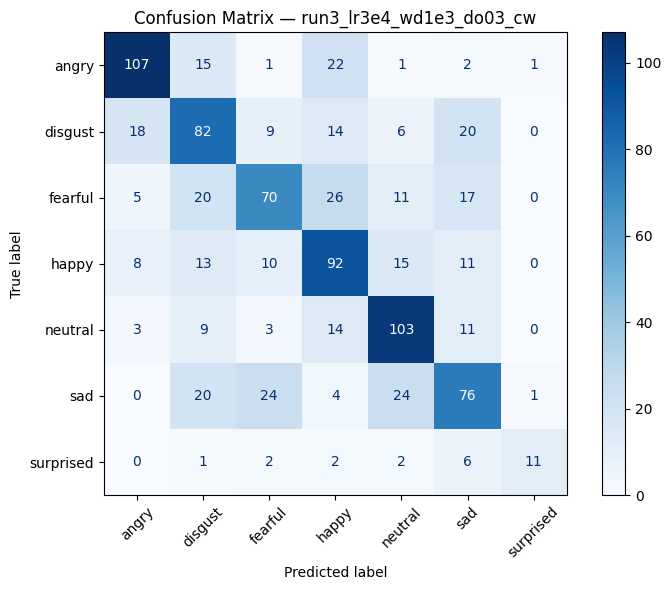

lr,██████████▄▄▄▄▄▄▂▂▂▂▁▁▁▁▁▁
test_acc,▁
test_macro_f1,▁
train_acc,▁▂▃▃▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇██████
train_loss,█▇▆▆▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁
val_acc,▁▂▄▅▆▆▆▇▇▆▆▇▇███▇█████████
val_loss,█▆▅▃▂▃▁▁▂▁▂▂▂▃▄▃▅▄▅▅▅▆▆▆▆▇
val_macro_f1,▁▃▄▅▆▆▇▇▇▇▇█▇█▇█▇█████████
lr,2e-05
test_acc,0.5932
test_macro_f1,0.59304



  INICIANDO: run4_lr3e4_wd1e3_do05_nocw
  lr=0.0003  wd=0.001  dropout=0.5  class_weights=False



[20:40:02] Epoca 01/50 | Train loss 1.6887 acc 0.3239 | Val loss 1.6336 acc 0.3445 f1 0.2672 | lr 3.0e-04 | Time 4.5s


[20:40:06] Epoca 02/50 | Train loss 1.5140 acc 0.4270 | Val loss 1.5596 acc 0.3971 f1 0.3858 | lr 3.0e-04 | Time 4.7s


[20:40:11] Epoca 03/50 | Train loss 1.4286 acc 0.4714 | Val loss 1.5327 acc 0.4234 f1 0.3904 | lr 3.0e-04 | Time 4.5s


...

[20:42:08] Epoca 29/50 | Train loss 0.4250 acc 0.9445 | Val loss 1.5983 acc 0.5849 f1 0.5983 | lr 3.7e-05 | Time 4.6s
Early Stopping: 4/8 (best=0.6042)


[20:42:13] Epoca 30/50 | Train loss 0.4168 acc 0.9464 | Val loss 1.6260 acc 0.5933 f1 0.6031 | lr 3.7e-05 | Time 4.8s
Early Stopping: 5/8 (best=0.6042)


[20:42:18] Epoca 31/50 | Train loss 0.4080 acc 0.9537 | Val loss 1.6320 acc 0.5742 f1 0.5867 | lr 1.9e-05 | Time 4.6s
Early Stopping: 6/8 (best=0.6042)


[20:42:22] Epoca 32/50 | Train loss 0.3884 acc 0.9623 | Val loss 1.6345 acc 0.5766 f1 0.5897 | lr 1.9e-05 | Time 4.5s
Early Stopping: 7/8 (best=0.6042)


[20:42:27] Epoca 33/50 | Train loss 0.3900 acc 0.9627 | Val loss 1.6125 acc 0.5837 f1 0.5936 | lr 1.9e-05 | Time 4.4s
Early Stopping: 8/8 (best=0.6042)
Early stopping en epoch 33 (best val_f1=0.6042)

--- RESULTADO TEST [run4_lr3e4_wd1e3_do05_nocw] ---
  best_epoch=25  best_val_f1=0.6042
  test_macro_f1=0.5772  test_acc=0.5932
              precision    recall  f1-score   support

       angry       0.72      0.73      0.72       149
     disgust       0.54      0.51      0.52       149
     fearful       0.63      0.54      0.58       149
       happy       0.55      0.59      0.57       149
     neutral       0.55      0.77      0.64       143
         sad       0.57      0.46      0.51       149
   surprised       0.69      0.38      0.49        24

    accuracy                           0.59       912
   macro avg       0.61      0.57      0.58       912
weighted avg       0.60      0.59      0.59       912



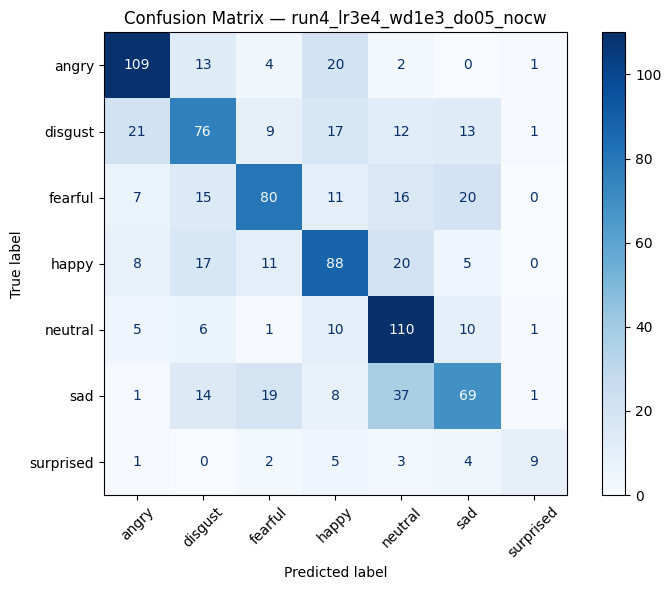

lr,████████████▄▄▄▄▄▄▄▄▄▂▂▂▂▂▂▁▁▁▁▁▁
test_acc,▁
test_macro_f1,▁
train_acc,▁▂▃▃▃▄▄▄▅▅▅▅▅▆▆▆▇▇▇▇▇▇▇▇█████████
train_loss,█▇▇▆▆▆▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val_acc,▁▂▃▅▅▆▆▆▆▇▇▇▇▇▇█▇▇█▇▇▇████▇▇██▇██
val_loss,█▆▆▄▂▂▂▁▂▁▂▁▂▂▄▃▄▄▄▄▅▅▅▆▆▇▇▇▇████
val_macro_f1,▁▃▄▅▆▆▆▇▇▇▆▇▇▇▇██████████████████
lr,2e-05
test_acc,0.5932
test_macro_f1,0.57723


In [15]:
# ─── Entrenamiento multi-experimento con W&B ──────────────────────────────────
all_run_results = []

for run_cfg in RUN_MATRIX:
    run_name           = run_cfg["run_name"]
    lr                 = run_cfg["lr"]
    weight_decay       = run_cfg["weight_decay"]
    classifier_dropout = run_cfg["classifier_dropout"]
    use_class_weights  = run_cfg["use_class_weights"]

    print(f"\n{'='*70}")
    print(f"  INICIANDO: {run_name}")
    print(f"  lr={lr}  wd={weight_decay}  dropout={classifier_dropout}  class_weights={use_class_weights}")
    print(f"{'='*70}\n")

    # Reproducibilidad por ejecucion
    random.seed(42)
    np.random.seed(42)
    torch.manual_seed(42)
    torch.cuda.manual_seed_all(42)

    # Dataloaders frescos para cada ejecucion
    train_loader, val_loader, test_loader = build_dataloaders()

    # Modelo con el dropout del clasificador según la ejecucion
    model = EmotionCGRU(num_classes=len(class_names), classifier_dropout=classifier_dropout).to(device)

    # Función de pérdida
    criterion_weights = class_weights_tensor if use_class_weights else None
    criterion = nn.CrossEntropyLoss(weight=criterion_weights, label_smoothing=LABEL_SMOOTHING)

    # Optimizador y scheduler
    optimizer    = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler    = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
    early_stopper = EarlyStopping(patience=EARLY_STOP_PATIENCE, min_delta=1e-4, mode='max')

    # Inicializar W&B
    if USE_WANDB:
        import wandb
        wandb.init(
            project=WANDB_PROJECT,
            group=WANDB_GROUP,
            name=run_name,
            config={
                "lr":                 lr,
                "weight_decay":       weight_decay,
                "classifier_dropout": classifier_dropout,
                "use_class_weights":  use_class_weights,
                "label_smoothing":    LABEL_SMOOTHING,
                "batch_size":         BATCH_SIZE,
                "epochs":             EPOCHS,
                "early_stop_patience": EARLY_STOP_PATIENCE,
                "max_grad_norm":      MAX_GRAD_NORM,
                "augment_online":     False,
                "model":              "EmotionCGRU",
            },
        )

    best_val_f1 = 0.0
    best_epoch  = 0
    best_state  = copy.deepcopy(model.state_dict())

    for epoch in range(1, EPOCHS + 1):
        start = time.time()

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device,
            epoch=epoch, max_grad_norm=MAX_GRAD_NORM,
        )
        val_loss, val_acc, val_f1 = evaluate(
            model, val_loader, criterion, device, epoch=epoch,
        )

        scheduler.step(val_f1)
        current_lr = optimizer.param_groups[0]['lr']
        elapsed = time.time() - start

        print(
            f"[{time.strftime('%H:%M:%S')}] Epoca {epoch:02d}/{EPOCHS:02d} | "
            f"Train loss {train_loss:.4f} acc {train_acc:.4f} | "
            f"Val loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f} | "
            f"lr {current_lr:.1e} | Time {elapsed:.1f}s"
        )

        if USE_WANDB:
            wandb.log({
                "train_loss":   train_loss,
                "train_acc":    train_acc,
                "val_loss":     val_loss,
                "val_acc":      val_acc,
                "val_macro_f1": val_f1,
                "lr":           current_lr,
            }, step=epoch)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch  = epoch
            best_state  = copy.deepcopy(model.state_dict())
            ckpt_path   = os.path.join(CHECKPOINT_DIR, f"{run_name}_best.pth")
            torch.save(best_state, ckpt_path)

        if early_stopper.step(val_f1):
            print(f"Early stopping en epoch {epoch} (best val_f1={best_val_f1:.4f})")
            break

    # ── Evaluación en test (una sola vez, con el mejor modelo por val_f1) ──────
    model.load_state_dict(best_state)
    y_true, y_pred = get_predictions(model, test_loader, device)
    test_f1  = f1_score(y_true, y_pred, average='macro', zero_division=0)
    test_acc = accuracy_score(y_true, y_pred)

    print(f"\n--- RESULTADO TEST [{run_name}] ---")
    print(f"  best_epoch={best_epoch}  best_val_f1={best_val_f1:.4f}")
    print(f"  test_macro_f1={test_f1:.4f}  test_acc={test_acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)
    fig_cm, ax_cm = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=ax_cm, cmap='Blues', xticks_rotation=45, values_format='d')
    ax_cm.set_title(f"Confusion Matrix — {run_name}")
    plt.tight_layout()
    plt.show()

    if USE_WANDB:
        # Guardar y loggear el checkpoint como artefacto
        artifact = wandb.Artifact(name=f"model_{run_name}", type="model")
        artifact.add_file(ckpt_path)
        wandb.log_artifact(artifact)

        # Métricas y artefactos de test
        report_dict = classification_report(
            y_true, y_pred, target_names=class_names, output_dict=True)
        wandb.log({
            "test_macro_f1":       test_f1,
            "test_acc":            test_acc,
            "confusion_matrix":    wandb.Image(fig_cm),
            "classification_report": wandb.Table(
                columns=["class", "precision", "recall", "f1-score", "support"],
                data=[
                    [c,
                     report_dict[c]["precision"],
                     report_dict[c]["recall"],
                     report_dict[c]["f1-score"],
                     int(report_dict[c]["support"])]
                    for c in class_names
                ],
            ),
        })
        wandb.finish()

    all_run_results.append({
        "run_name":      run_name,
        "best_val_f1":   round(best_val_f1, 4),
        "best_epoch":    best_epoch,
        "test_macro_f1": round(test_f1, 4),
        "test_acc":      round(test_acc, 4),
    })
    plt.close('all')


### 5. Resumen de experimentos y evaluación final


In [16]:
# Tabla resumen de la experimentación -----------------------------------------------
summary_df = pd.DataFrame(all_run_results)
summary_df = summary_df.sort_values("best_val_f1", ascending=False).reset_index(drop=True)

print("\n" + "="*70)
print("  RESUMEN FINAL DE EXPERIMENTOS")
print("="*70)
print(summary_df.to_string(index=False))
display(summary_df)



  RESUMEN FINAL DE EXPERIMENTOS
                  run_name  best_val_f1  best_epoch  test_macro_f1  test_acc
  run1_lr3e4_wd1e3_do05_cw       0.6139          23         0.5926    0.5987
run4_lr3e4_wd1e3_do05_nocw       0.6042          25         0.5772    0.5932
  run3_lr3e4_wd1e3_do03_cw       0.5971          18         0.5930    0.5932
  run2_lr5e4_wd1e3_do05_cw       0.5792          14         0.5830    0.5855


,run_name,best_val_f1,best_epoch,test_macro_f1,test_acc
0,run1_lr3e4_wd1e3_do05_cw,0.6139,23,0.5926,0.5987
1,run4_lr3e4_wd1e3_do05_nocw,0.6042,25,0.5772,0.5932
2,run3_lr3e4_wd1e3_do03_cw,0.5971,18,0.5930,0.5932
3,run2_lr5e4_wd1e3_do05_cw,0.5792,14,0.5830,0.5855


## Modelos tradicionales de ML con Grid Search

Se entrenan **Random Forest** y **XGBoost** con búsqueda de hiperparámetros usando
`GridSearchCV` con `PredefinedSplit` para respetar la partición train/val sin filtrar
el set de test. Antes del entrenamiento se aplica **SMOTE** exclusivamente sobre el
conjunto de entrenamiento para balancear la clase minoritaria `surprised`.


In [17]:
def pack_to_numpy(pack):
    x = pack['x'].float().reshape(pack['x'].shape[0], -1).numpy()
    y = pack['y'].numpy()
    return x, y

X_train, y_train = pack_to_numpy(train_pack)
X_val, y_val = pack_to_numpy(val_pack)
X_test, y_test = pack_to_numpy(test_pack)
X_train_val = np.concatenate([X_train, X_val], axis=0)
y_train_val = np.concatenate([y_train, y_val], axis=0)


print(f"Muestras por clase:")
for cls, idx in sorted(class_to_idx.items(), key=lambda kv: kv[1]):
    print(f"  {cls:12s} (idx={idx}): {(y_train == idx).sum()}")

# -1 = train, 0 = val (PredefinedSplit usa índice de fold)
test_fold = np.concatenate([
    -1 * np.ones(len(X_train), dtype=int),
     np.zeros(len(X_val), dtype=int)
])
predefined_split = PredefinedSplit(test_fold)
print(f"\nTamaño total train+val para GridSearchCV: {len(X_train_val)}")
print(f"(train={len(X_train)}, val={len(X_val)}, test={len(X_test)} — test NO entra en GridSearch)")


Muestras por clase:
  angry        (idx=0): 1178
  disgust      (idx=1): 1178
  fearful      (idx=2): 1178
  happy        (idx=3): 1178
  neutral      (idx=4): 1100
  sad          (idx=5): 1178
  surprised    (idx=6): 432

Tamaño total train+val para GridSearchCV: 8258
(train=7422, val=836, test=912 — test NO entra en GridSearch)


In [ ]:
# ── Random Forest con Grid Search ────────────────────────────────────────────
param_grid_rf = {
    'n_estimators': [20, 60],
    'max_depth': [20, None],
    'min_samples_split': [2, 6],
    'min_samples_leaf': [1, 7],
    'max_features': ['log2'],
}

rf = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)
grid_rf = GridSearchCV(
    rf,
    param_grid=param_grid_rf,
    cv=predefined_split,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
)
grid_rf.fit(X_train_val, y_train_val)

print('RF — Mejores parámetros:', grid_rf.best_params_)
print('RF — Mejor f1_macro (val):', grid_rf.best_score_)


Fitting 1 folds for each of 16 candidates, totalling 16 fits
RF — Mejores parámetros: {'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 7, 'min_samples_split': 2, 'n_estimators': 60}
RF — Mejor f1_macro (val): 0.33904274294423553


=== Random Forest — Evaluación en Test ===
              precision    recall  f1-score   support

       angry       0.62      0.62      0.62       149
     disgust       0.33      0.26      0.29       149
     fearful       0.28      0.12      0.17       149
       happy       0.40      0.34      0.37       149
     neutral       0.34      0.49      0.40       143
         sad       0.48      0.48      0.48       149
   surprised       0.10      0.42      0.16        24

    accuracy                           0.38       912
   macro avg       0.36      0.39      0.35       912
weighted avg       0.40      0.38      0.38       912



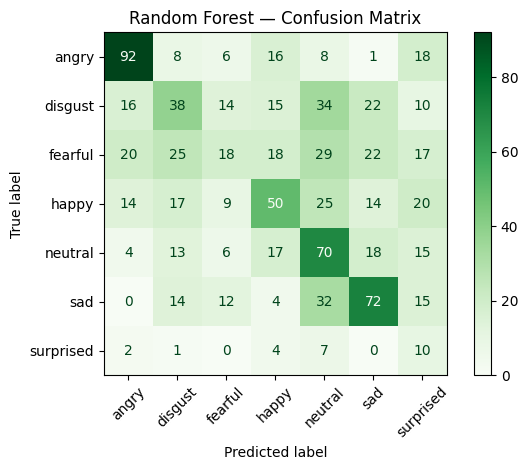

In [ ]:
best_rf = RandomForestClassifier(**grid_rf.best_params_, random_state=42, class_weight='balanced', n_jobs=-1)
best_rf.fit(X_train_val, y_train_val)
y_pred_rf = best_rf.predict(X_test)
print('=== Random Forest — Evaluación en Test ===')
print(classification_report(y_test, y_pred_rf, target_names=class_names))

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=class_names).plot(cmap='Greens', xticks_rotation=45)
plt.title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# ── XGBoost con Grid Search ───────────────────────────────────────────────────
param_grid_xgb = {
    'n_estimators': [30],
    'max_depth': [3],
    'learning_rate': [0.01],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
}

xgb_clf = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(class_names),
    tree_method='hist',
    use_label_encoder=False,
    eval_metric='merror',
    random_state=42,
    n_jobs=-1,
)
grid_xgb = GridSearchCV(
    xgb_clf,
    param_grid=param_grid_xgb,
    cv=predefined_split,
    scoring='f1_macro',
    n_jobs=-1, # Changed from 1 to -1 to use all available cores
    verbose=1,
)
grid_xgb.fit(X_train_val, y_train_val)

print('XGB — Mejores parámetros:', grid_xgb.best_params_)
print('XGB — Mejor f1_macro (val):', grid_xgb.best_score_)

Fitting 1 folds for each of 1 candidates, totalling 1 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:51:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGB — Mejores parámetros: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 30, 'subsample': 0.8}
XGB — Mejor f1_macro (val): 0.29780300025493417


=== XGBoost — Evaluación en Test ===
              precision    recall  f1-score   support

       angry       0.47      0.68      0.55       149
     disgust       0.35      0.36      0.35       149
     fearful       0.31      0.20      0.24       149
       happy       0.33      0.38      0.35       149
     neutral       0.30      0.10      0.15       143
         sad       0.41      0.62      0.49       149
   surprised       0.00      0.00      0.00        24

    accuracy                           0.38       912
   macro avg       0.31      0.33      0.31       912
weighted avg       0.35      0.38      0.35       912



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


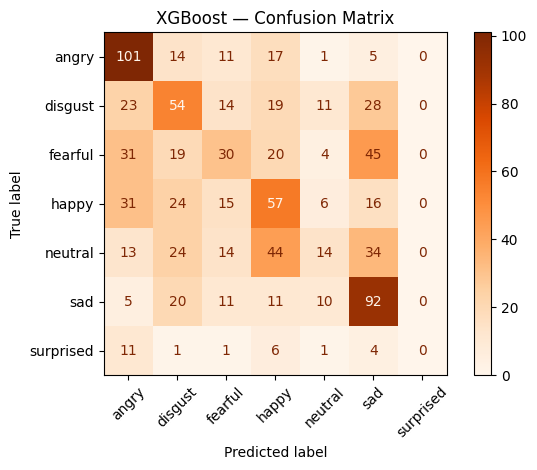

In [ ]:
best_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
print('=== XGBoost — Evaluación en Test ===')
print(classification_report(y_test, y_pred_xgb, target_names=class_names))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(cm_xgb, display_labels=class_names).plot(cmap='Oranges', xticks_rotation=45)
plt.title('XGBoost — Confusion Matrix')
plt.tight_layout()
plt.show()
